In [4]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Menyembunyikan peringatan non-kritis
warnings.filterwarnings('ignore')

# Konfigurasi gaya visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

# 1. Konfigurasi Path
DATA_DIR = "../data/csiro-biomass"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")

print("Memuat dataset...")
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f"Jumlah total baris Data Train : {train_df.shape[0]}")
print(f"Jumlah total baris Data Test  : {test_df.shape[0]}")

# Buat kolom image_id murni dari image_path
train_df['image_id'] = train_df['image_path'].apply(lambda x: os.path.basename(x))
unique_images = train_df['image_id'].nunique()
print(f"Jumlah gambar unik di Data Train : {unique_images}")

Memuat dataset...
Jumlah total baris Data Train : 1785
Jumlah total baris Data Test  : 5
Jumlah gambar unik di Data Train : 357


In [5]:
print("--- Ringkasan Statistik Per Target Biomassa (Gram) ---")
display(train_df.groupby('target_name')['target'].describe())

--- Ringkasan Statistik Per Target Biomassa (Gram) ---


,count,mean,std,min,25%,50%,75%,max
target_name,,,,,,,,
Dry_Clover_g,357.0,6.649692,12.117761,0.00,0.0000,1.4235,7.2429,71.7865
Dry_Dead_g,357.0,12.044548,12.402007,0.00,3.2000,7.9809,17.6378,83.8407
Dry_Green_g,357.0,26.624722,25.401232,0.00,8.8000,20.8000,35.0834,157.9836
Dry_Total_g,357.0,45.318097,27.984015,1.04,25.2715,40.3000,57.8800,185.7000
GDM_g,357.0,33.274414,24.935822,1.04,16.0261,27.1082,43.6757,157.9836


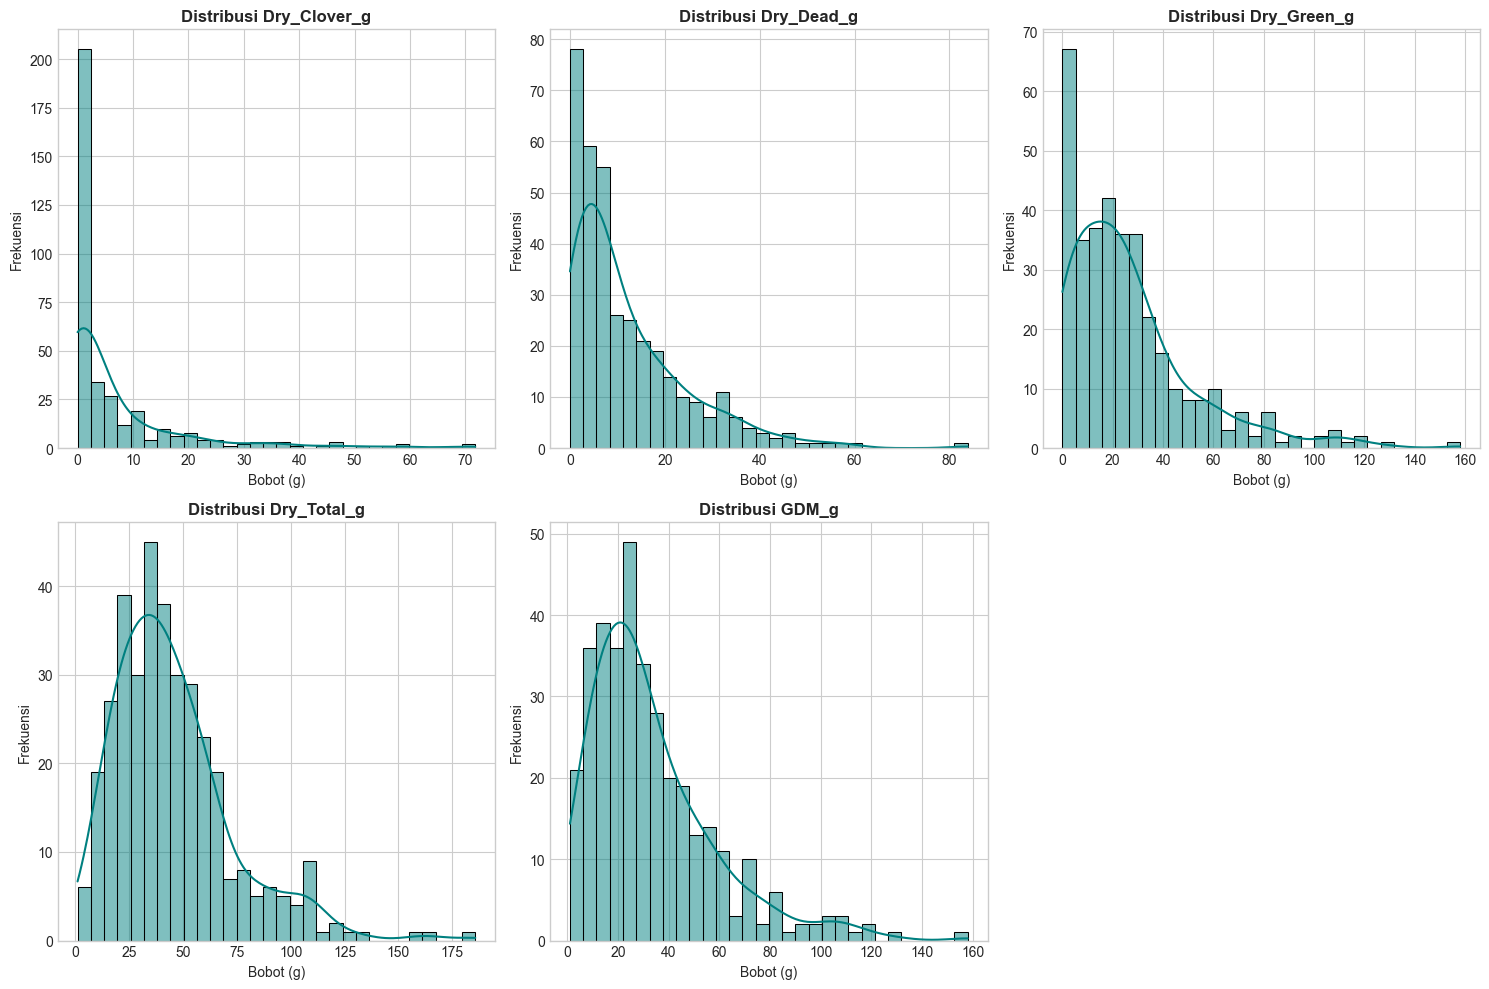

In [6]:
target_names = train_df['target_name'].unique()

plt.figure(figsize=(15, 10))
for i, target in enumerate(target_names):
    plt.subplot(2, 3, i+1)
    subset = train_df[train_df['target_name'] == target]['target']
    sns.histplot(subset, kde=True, color='teal', bins=30)
    plt.title(f'Distribusi {target}', fontsize=12, fontweight='bold')
    plt.xlabel('Bobot (g)')
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

--- Tampilan Data Setelah Di-pivot (Wide Format) ---


target_name,image_id,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,ID1011485656.jpg,0.0000,31.9984,16.2751,48.2735,16.2750
1,ID1012260530.jpg,0.0000,0.0000,7.6000,7.6000,7.6000
2,ID1025234388.jpg,6.0500,0.0000,0.0000,6.0500,6.0500
3,ID1028611175.jpg,0.0000,30.9703,24.2376,55.2079,24.2376
4,ID1035947949.jpg,0.4343,23.2239,10.5261,34.1844,10.9605


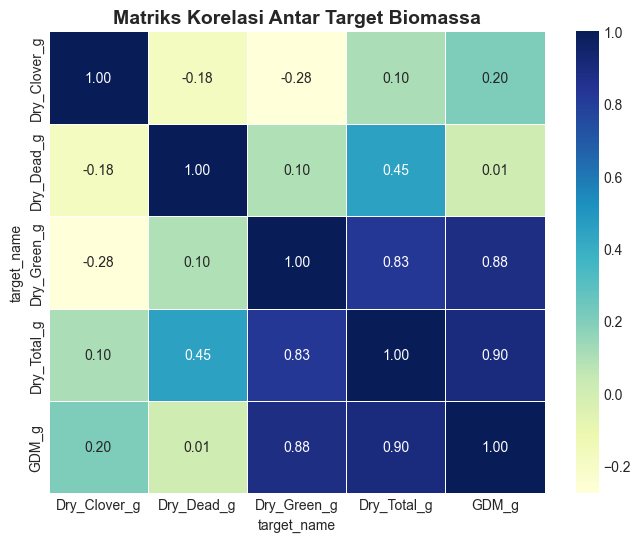

In [7]:
# Pivot tabel agar 1 baris melambangkan 1 gambar dengan 5 kolom target
train_wide = train_df.pivot(index='image_id', columns='target_name', values='target').reset_index()

# Tampilkan 5 baris pertama hasil pivot
print("--- Tampilan Data Setelah Di-pivot (Wide Format) ---")
display(train_wide.head())

# Matriks Korelasi
plt.figure(figsize=(8, 6))
correlation_matrix = train_wide[target_names].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Antar Target Biomassa', fontsize=14, fontweight='bold')
plt.show()

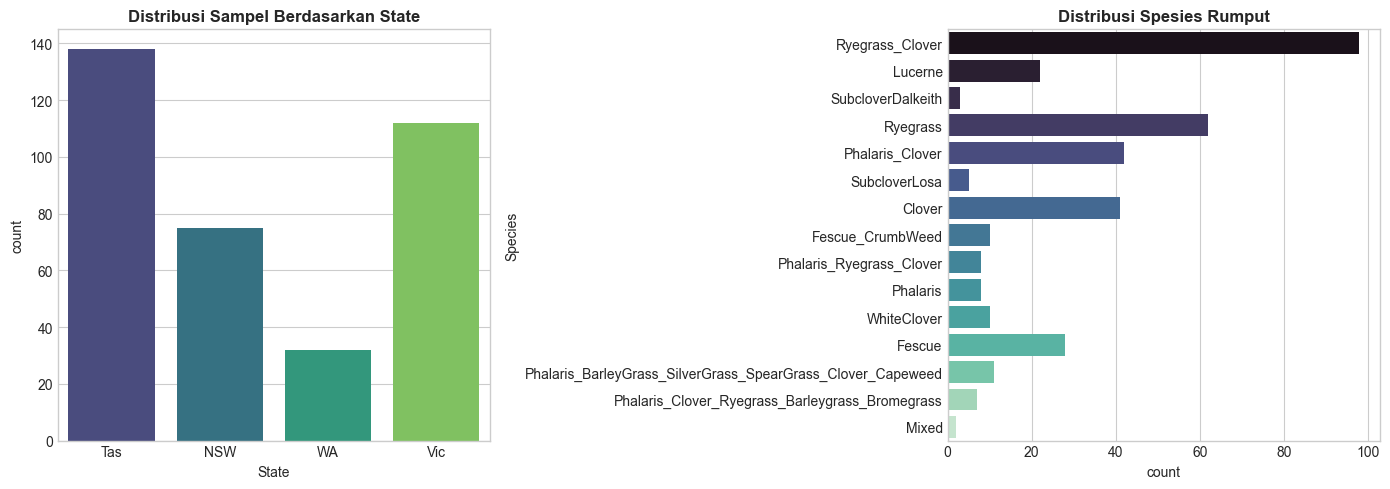

In [8]:
# Ambil metadata unik per gambar
meta_cols = ['image_id', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']
meta_df = train_df[meta_cols].drop_duplicates().reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi Negara Bagian (State)
sns.countplot(data=meta_df, x='State', ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Sampel Berdasarkan State', fontsize=12, fontweight='bold')

# Distribusi Spesies Rumput
sns.countplot(data=meta_df, y='Species', ax=axes[1], palette='mako')
axes[1].set_title('Distribusi Spesies Rumput', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

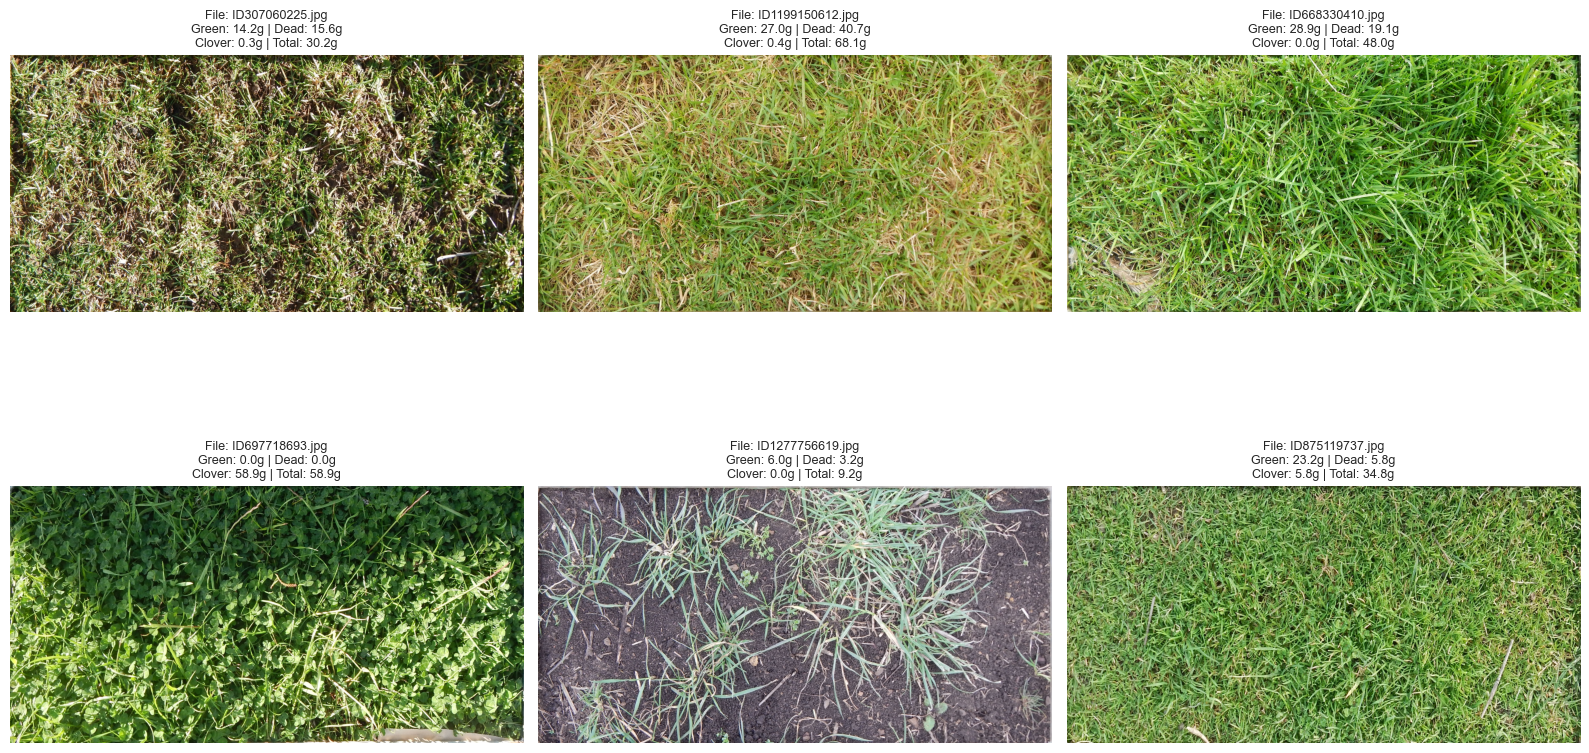

In [9]:
def plot_sample_images_long(df_wide, base_data_dir, num_samples=6):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    sample_df = df_wide.sample(n=num_samples, random_state=42).reset_index(drop=True)
    
    for idx, row in sample_df.iterrows():
        img_filename = row['image_id']
        # Path lengkap ke gambar
        img_path = os.path.join(base_data_dir, "train_images", img_filename)
        if not os.path.exists(img_path):
            img_path = os.path.join(base_data_dir, "train", img_filename)
            
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].axis('off')
            
            title_text = (
                f"File: {img_filename}\n"
                f"Green: {row.get('Dry_Green_g', 0):.1f}g | Dead: {row.get('Dry_Dead_g', 0):.1f}g\n"
                f"Clover: {row.get('Dry_Clover_g', 0):.1f}g | Total: {row.get('Dry_Total_g', 0):.1f}g"
            )
            axes[idx].set_title(title_text, fontsize=9)
        else:
            axes[idx].text(0.5, 0.5, f"Gambar {img_filename}\ntidak ditemukan", ha='center', va='center')
            axes[idx].axis('off')
            
    plt.tight_layout()
    plt.show()

plot_sample_images_long(train_wide, DATA_DIR, num_samples=6)